# V0.2 — The criticality coincidence

**Tier 0 / Verification Protocol §V0.2.** Builds on **V0.1 (passed)** — the Voigt–Reuss gap is a valid, tight, bounded per-cell trust scalar. Here we test the claim that makes adaptive resolution *safe*: that this scalar degrades **at or before** the cell becomes structurally critical.

### Claim (falsifiable)
As a char wedge deepens (char fraction χ ↑), the V–R gap rises **monotonically** and crosses the refine threshold `T_hi` at a χ **≤** the χ at which the cell reaches structural criticality (peak load-bearing stress reaching cohesive capacity) — for **every** applied load case.

### Load-bearing because
This is what makes *"refine where untrustworthy"* automatically spend resolution exactly where it matters — a char wedge approaching failure. If the gap instead spiked *after* failure, the system would refine too late and the adaptive-resolution economy would be unsafe in the violent regime.

### Oracle (independent ground truth)
DNS of the charring cell under sustained load. From the same 6 unit-strain solves V0.1 uses, we reconstruct the **local stress field** (`dns_elasticity_3d` localization) and track two distance-to-failure measures: **peak von-Mises stress in the load-bearing wood vs a cohesive strength** (the threshold), plus **stored elastic strain energy** (supporting). `χ` = char volume fraction.

### Pre-registered pass criteria (frozen before running)
| # | Metric | Threshold | Failure → outcome |
|---|---|---|---|
| A | refine-trigger χ `≤` criticality-onset χ | **100%** of load cases | **CONSTRAIN**: add explicit stress/energy criterion to the refinement predicate |
| B | gap monotone in χ (no late spike) | **> 95%** of steps | CONSTRAIN |
| — | rank-corr(gap, 1/distance-to-failure) | reported (not gated) | — |

In [1]:
"""(1) Setup — imports, paths, frozen constants, load cases."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import dns_elasticity_3d as _dns
from dns_elasticity_3d import effective_stiffness
from homogenization import voigt_bound, reuss_bound, relative_gap
from failure import peak_stress, stored_energy, distance_to_failure
import cells

np.set_printoptions(precision=4, suppress=True)
np.random.seed(0)

# ---- PRE-REGISTERED constants (frozen) ----
T_HI          = 0.30     # refine threshold on the V-R gap (V0.1: "useful gap < 30%")
CONTRAST      = 60.0     # char/wood stiffness contrast (heavy char)
EPS0          = 1.0e-3   # applied macro-strain magnitude
SAFETY_FACTOR = 2.0      # intact cell sits at SF=2; cohesive strength sigma_c is derived
                         # as SF x (max intact peak stress) -> failure when local stress doubles.
                         # (Principled, self-calibrating; keeps criticality mid-sweep so the
                         #  "gap warns BEFORE failure" claim is actually exercised.)
N             = 24       # DNS resolution
# char-wedge deepening sweep -> chi; densified near onset (the gap & criticality both
# turn on at small chi for heavy char, so resolution there is where the test lives).
DEPTHS        = np.unique(np.concatenate([np.linspace(0.0, 0.30, 16),
                                          np.linspace(0.35, 0.95, 8)]))
MONO_TOL      = 1e-6     # numerical slack for "non-decreasing"

# ---- load cases: macroscopic Voigt strain vectors (scaled by EPS0) ----
LOADS = {
    "uniaxial-x (across wedge)": np.array([1, 0, 0, 0, 0, 0.0]) * EPS0,
    "uniaxial-y":                np.array([0, 1, 0, 0, 0, 0.0]) * EPS0,
    "uniaxial-z (wedge axis)":   np.array([0, 0, 1, 0, 0, 0.0]) * EPS0,
    "shear-xz (wedge plane)":    np.array([0, 0, 0, 0, 1, 0.0]) * EPS0,
    "shear-xy":                  np.array([0, 0, 0, 0, 0, 1.0]) * EPS0,
}
print(f"DNS backend = {'GPU (cupy CG)' if _dns._HAS_GPU else 'CPU (sparse LU)'}")
print(f"sweep: {len(DEPTHS)} depths x {len(LOADS)} load cases; N={N}; T_hi={T_HI}; "
      f"safety_factor={SAFETY_FACTOR}")


DNS backend = GPU (cupy CG)
sweep: 24 depths x 5 load cases; N=24; T_hi=0.3; safety_factor=2.0


## (2) Sweep the charring cell

Deepen the char wedge across the depth sweep. For each cell: the trust scalar (max-over-directions V–R gap, load-independent), and for each load case the peak wood von-Mises stress → distance-to-failure, plus stored elastic energy.

In [2]:
"""(2) Calibrate sigma_c from the intact cell, then run the sweep."""
# calibration: intact (chi=0) peak stress per load -> sigma_c = SF * max intact peak
_intact = cells.char_wedge_cell(n=N, depth=0.0, contrast=CONTRAST)
_, loc0 = effective_stiffness(_intact.grid, _intact.materials, return_localization=True)
intact_peak = {k: peak_stress(loc0, e, phase=0) for k, e in LOADS.items()}
SIGMA_C = SAFETY_FACTOR * max(intact_peak.values())
print(f"calibration: max intact peak = {max(intact_peak.values()):.5f}  ->  "
      f"sigma_c = {SIGMA_C:.5f}  (SF={SAFETY_FACTOR})\n")

chi   = []                                   # char volume fraction per step
gap   = []                                   # trust scalar (max V-R gap) per step
dtf   = {k: [] for k in LOADS}               # distance-to-failure per load case
energy = {k: [] for k in LOADS}              # stored elastic energy per load case

for depth in DEPTHS:
    c = cells.char_wedge_cell(n=N, depth=float(depth), contrast=CONTRAST)
    _, loc = effective_stiffness(c.grid, c.materials, return_localization=True)

    C_v = voigt_bound(c.fractions, c.C_phases)
    C_r = reuss_bound(c.fractions, c.C_phases)
    chi.append(c.meta["char_fraction"])
    gap.append(float(relative_gap(C_v, C_r).max()))

    for k, e in LOADS.items():
        p = peak_stress(loc, e, phase=0)     # wood is phase 0
        dtf[k].append(distance_to_failure(p, SIGMA_C))
        energy[k].append(stored_energy(loc, e))

chi = np.array(chi); gap = np.array(gap)
dtf = {k: np.array(v) for k, v in dtf.items()}
energy = {k: np.array(v) for k, v in energy.items()}
print(f"swept {len(chi)} cells; chi in [{chi.min():.3f}, {chi.max():.3f}]; "
      f"gap in [{gap.min():.3f}, {gap.max():.3f}]")


calibration: max intact peak = 0.00769  ->  sigma_c = 0.01538  (SF=2.0)



swept 24 cells; chi in [0.000, 0.472]; gap in [0.000, 1.757]


## (3) Metric A — ordering: refine fires at or before criticality

For each load case: `χ_refine` = first χ where the gap reaches `T_hi`; `χ_crit` = first χ where distance-to-failure ≤ 0 (peak stress reaches cohesive strength). The claim demands `χ_refine ≤ χ_crit` for **100%** of load cases — the trust scalar must warn *before* the cell fails. (A load case that never reaches criticality in the sweep trivially satisfies the claim.)

In [3]:
"""(3) Metric A — ordering of threshold crossings."""
def first_chi(condition):
    """smallest chi where condition (bool array over the sweep) is first true, else None."""
    idx = np.argmax(condition) if condition.any() else None
    return chi[idx] if idx is not None else None

chi_refine = first_chi(gap >= T_HI)
print(f"chi_refine (gap >= {T_HI}) = "
      f"{chi_refine:.3f}" if chi_refine is not None else "chi_refine = (never)")
print(f"{'load case':28s} {'chi_crit':>9s}  {'ordering (refine<=crit)':>24s}")
ordering_ok = []
for k in LOADS:
    chi_crit = first_chi(dtf[k] <= 0.0)
    if chi_crit is None:
        ok = True                              # never fails -> claim trivially holds
        crit_str = "(safe)"
    else:
        ok = (chi_refine is not None) and (chi_refine <= chi_crit + 1e-12)
        crit_str = f"{chi_crit:.3f}"
    ordering_ok.append(ok)
    print(f"{k:28s} {crit_str:>9s}  {'PASS' if ok else 'FAIL':>24s}")

METRIC_A_PASS = all(ordering_ok)
print(f"\n   => METRIC A (ordering, 100%) PASS: {METRIC_A_PASS}")


chi_refine (gap >= 0.3) = 0.021
load case                     chi_crit   ordering (refine<=crit)
uniaxial-x (across wedge)        0.021                      PASS
uniaxial-y                      (safe)                      PASS
uniaxial-z (wedge axis)          0.059                      PASS
shear-xz (wedge plane)           0.028                      PASS
shear-xy                         0.021                      PASS

   => METRIC A (ordering, 100%) PASS: True


## (4) Metric B — monotonicity (no late spike) + supporting correlation

The gap must rise **monotonically** with χ (so it gives early warning, never a post-failure spike): fraction of non-decreasing steps must exceed **95%**. Supporting evidence: the rank correlation between the gap and the inverse distance-to-failure (both should grow together toward criticality).

In [4]:
"""(4) Metric B — monotonicity of gap(chi); supporting rank correlation."""
dgap = np.diff(gap)
frac_nondec = float(np.mean(dgap >= -MONO_TOL))
METRIC_B_PASS = frac_nondec > 0.95
print(f"gap monotonicity: {frac_nondec:.0%} of {len(dgap)} steps non-decreasing  "
      f"(threshold > 95%)")
print(f"   => METRIC B (monotonicity) PASS: {METRIC_B_PASS}")

print("\nsupporting — rank corr(gap, 1/distance-to-failure) over pre-failure region:")
for k in LOADS:
    d = dtf[k]
    pre = d > 1e-6                              # only where still safe (1/d finite & meaningful)
    if pre.sum() >= 3:
        rho, _ = spearmanr(gap[pre], 1.0 / d[pre])
        print(f"   {k:28s} rho = {rho:+.3f}")
    else:
        print(f"   {k:28s} (too few pre-failure points)")


gap monotonicity: 100% of 23 steps non-decreasing  (threshold > 95%)
   => METRIC B (monotonicity) PASS: True

supporting — rank corr(gap, 1/distance-to-failure) over pre-failure region:
   uniaxial-x (across wedge)    (too few pre-failure points)
   uniaxial-y                   rho = +0.892
   uniaxial-z (wedge axis)      rho = +0.966
   shear-xz (wedge plane)       rho = +0.684
   shear-xy                     (too few pre-failure points)


## (5) Plots

(a) the trust scalar (gap) vs χ with the `T_hi` refine line and per-load criticality markers — the visual statement of the coincidence; (b) distance-to-failure trajectories; (c) stored elastic energy.

saved figure -> /workspace/nebula/verification_notebooks/phase0/results/V0_2_criticality_coincidence.png


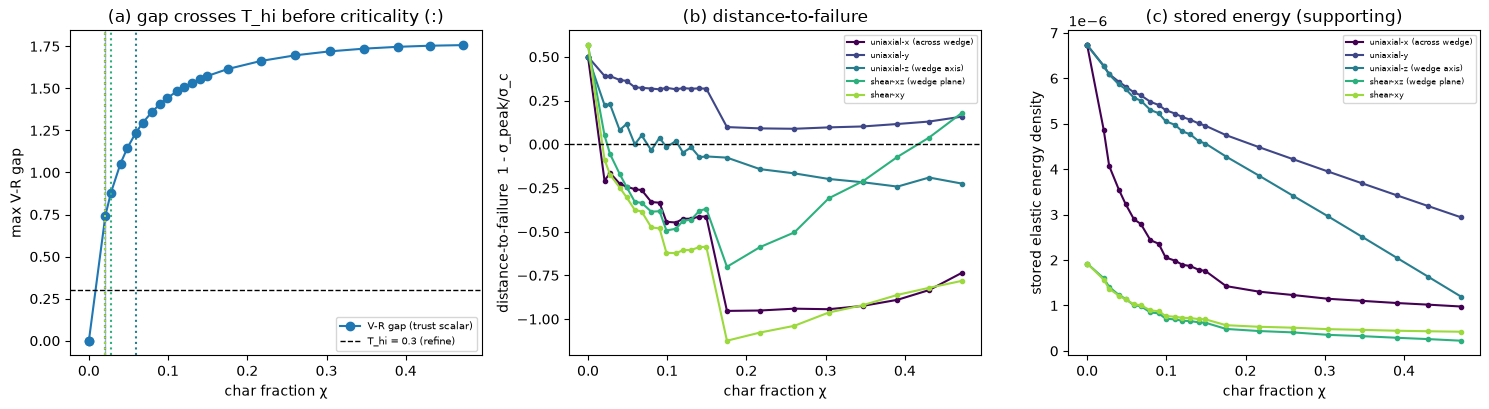

In [5]:
"""(5) Figures."""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(LOADS)))

# (a) trust scalar vs chi + refine line + criticality markers
ax[0].plot(chi, gap, "-o", color="tab:blue", label="V-R gap (trust scalar)")
ax[0].axhline(T_HI, ls="--", color="k", lw=1, label=f"T_hi = {T_HI} (refine)")
if chi_refine is not None:
    ax[0].axvline(chi_refine, ls="-", color="tab:blue", lw=1, alpha=0.5)
for (k, _), col in zip(LOADS.items(), colors):
    cc = first_chi(dtf[k] <= 0.0)
    if cc is not None:
        ax[0].axvline(cc, ls=":", color=col, lw=1.5)
ax[0].set_xlabel("char fraction χ"); ax[0].set_ylabel("max V-R gap")
ax[0].set_title("(a) gap crosses T_hi before criticality (:)"); ax[0].legend(fontsize=7)

# (b) distance-to-failure trajectories
for (k, _), col in zip(LOADS.items(), colors):
    ax[1].plot(chi, dtf[k], "-o", ms=3, color=col, label=k)
ax[1].axhline(0.0, ls="--", color="k", lw=1)
ax[1].set_xlabel("char fraction χ"); ax[1].set_ylabel("distance-to-failure  1 - σ_peak/σ_c")
ax[1].set_title("(b) distance-to-failure"); ax[1].legend(fontsize=6)

# (c) stored elastic energy
for (k, _), col in zip(LOADS.items(), colors):
    ax[2].plot(chi, energy[k], "-o", ms=3, color=col, label=k)
ax[2].set_xlabel("char fraction χ"); ax[2].set_ylabel("stored elastic energy density")
ax[2].set_title("(c) stored energy (supporting)"); ax[2].legend(fontsize=6)

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase0" / "results"
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V0_2_criticality_coincidence.png", dpi=110)
print(f"saved figure -> {outdir / 'V0_2_criticality_coincidence.png'}")
plt.show()


## (6) Frozen verdict

In [6]:
"""(6) Verdict against the pre-registered criteria."""
def verdict(name, passed, detail, fail_outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:30s} {'PASS' if passed else f'FAIL -> {fail_outcome}'}")
    print(f"        {detail}")

n_fail_cases = sum(first_chi(dtf[k] <= 0.0) is not None for k in LOADS)
print("=" * 74)
print("V0.2 — THE CRITICALITY COINCIDENCE — VERDICT")
print("=" * 74)
verdict("A. ordering (100% loads)", METRIC_A_PASS,
        f"refine fires at χ={chi_refine:.3f}; "
        f"{n_fail_cases}/{len(LOADS)} load cases reach criticality, all refine-first",
        "CONSTRAIN: add stress/energy refine criterion")
verdict("B. monotonicity (>95%)", METRIC_B_PASS,
        f"{frac_nondec:.0%} of steps non-decreasing (no late spike)",
        "CONSTRAIN")

ALL_PASS = METRIC_A_PASS and METRIC_B_PASS
print("=" * 74)
print(f"  V0.2 OVERALL: {'PASS — worst-for-homogenization = most-important; refine fires in time' if ALL_PASS else 'FAIL — CONSTRAIN: criticality needs an explicit refine trigger'}")
print("=" * 74)


V0.2 — THE CRITICALITY COINCIDENCE — VERDICT
  [OK ] A. ordering (100% loads)       PASS
        refine fires at χ=0.021; 4/5 load cases reach criticality, all refine-first
  [OK ] B. monotonicity (>95%)         PASS
        100% of steps non-decreasing (no late spike)
  V0.2 OVERALL: PASS — worst-for-homogenization = most-important; refine fires in time
